In [109]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Function to find file by its extension

In [110]:
import os

def find_file_by_ext(folder_path, extensions):
    """
    Returns the first file in folder_path matching any extension in extensions
    """
    for f in os.listdir(folder_path):
        if f.lower().endswith(extensions):
            return os.path.join(folder_path, f)
    return None


### Function to find images

In [111]:
def find_all_images(folder_path):
    return sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])


### Quick view of metadata contents

In [112]:
import json, gzip, lzma

def load_metadata(path):
    if path.endswith(".gz"):
        with gzip.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)
    elif path.endswith(".xz"):
        with lzma.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)

# Test loading of metadata with 1 sample
meta_path = r".\datasets\Data\aashnashroff_969148_3000403601659402518_25980_65\2022-12-24_15-33-23_UTC.json.xz"
meta = load_metadata(meta_path)
print(meta.keys())
print(meta['node'].keys())
for k, v in meta['node'].items():
    print("KEY:", k)
    print("VALUE:", v)
    print("-" * 40)


dict_keys(['node', 'instaloader'])
dict_keys(['__typename', 'id', 'gating_info', 'fact_check_overall_rating', 'fact_check_information', 'media_overlay_info', 'sensitivity_friction_info', 'sharing_friction_info', 'dimensions', 'display_url', 'display_resources', 'is_video', 'media_preview', 'tracking_token', 'edge_media_to_tagged_user', 'accessibility_caption', 'edge_media_to_caption', 'shortcode', 'edge_media_to_comment', 'edge_media_to_sponsor_user', 'comments_disabled', 'taken_at_timestamp', 'edge_media_preview_like', 'owner', 'location', 'viewer_has_liked', 'viewer_has_saved', 'viewer_has_saved_to_collection', 'viewer_in_photo_of_you', 'viewer_can_reshare', 'thumbnail_src', 'thumbnail_resources', 'edge_sidecar_to_children'])
KEY: __typename
VALUE: GraphSidecar
----------------------------------------
KEY: id
VALUE: 3000403601659402518
----------------------------------------
KEY: gating_info
VALUE: None
----------------------------------------
KEY: fact_check_overall_rating
VALUE: N

### Extract metadata

In [113]:
import os
import json
import gzip
import lzma
from datetime import datetime, timezone

DATA_DIR = r".\datasets\Data"

posts = []

for post_id in os.listdir(DATA_DIR):
    post_path = os.path.join(DATA_DIR, post_id)

    if not os.path.isdir(post_path):
        continue

    # --- Read metadata ---
    meta_path = find_file_by_ext(post_path, (".json.gz", ".json.xz"))

    metadata = {}

    if meta_path:
        if meta_path.endswith(".gz"):
            with gzip.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)
        elif meta_path.endswith(".xz"):
            with lzma.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)

    # --- Extract metadata from nested JSON ---
    node = metadata.get('node', {})

    # === Owner metrics ===
    followers = node.get("owner", {}).get("edge_followed_by", {}).get("count", 0)
    following = node.get("owner", {}).get("edge_follow", {}).get("count", 0)
    user_id = node.get("owner", {}).get("id", None)#.get("count", 0)

    # === Post metrics ===
    # Timestamp (convert from UNIX epoch to readable)
    ts = node.get('taken_at_timestamp', None)
    if ts:
        publish_timestamp = datetime.fromtimestamp(ts, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S')
    else:
        publish_timestamp = ''

    # Location
    has_location = 1 if node.get("location") else 0

    # Flag carousel posts (> 1 image)
    sidecar = node.get("edge_sidecar_to_children")

    is_carousel = (
        1 if sidecar and len(sidecar.get("edges", [])) > 0 else 0
    )

    # Get number of images in post
    if sidecar and "edges" in sidecar:
        num_images = len(sidecar["edges"])
    else:
        num_images = 1  # single-image post

    # Flag sponsored content
    sponsor_edge = node.get("edge_media_to_sponsor_user")

    is_sponsored = (
        1 if sponsor_edge and len(sponsor_edge.get("edges", [])) > 0 else 0
    )

    # === Engagement-related ===
    likes = node.get("edge_media_preview_like", {}).get("count", 0)
    comments = node.get("edge_media_to_comment", {}).get("count", 0)
    # Calculate engagement rate
    engagement_rate = (likes + comments) / max(followers, 1) # avoid division by 0


    # --- Read caption from text file ---
    caption_path = find_file_by_ext(post_path, (".txt",))

    if caption_path is None:
        caption = ""
    else:
        with open(caption_path, "r", encoding="utf-8", errors="ignore") as f:
            caption = f.read().strip()

    # --- Find Image / Video file ---
    # Filter out video posts for this project
    if metadata.get("is_video"):
        continue  # skip video posts

    # Extract 1st image, save local relative path
    images = find_all_images(post_path)
    image_path = images[0] if images else None

    if image_path is None:
        continue  # skip posts without images

    posts.append({
        # Owner metrics
        "user_id": user_id,
        "followers": followers,
        "following": following,
        # Post metrics
        "publish_timestamp": publish_timestamp,
        "has_location": has_location,
        "is_carousel": is_carousel,
        "num_images": num_images,
        "is_sponsored": is_sponsored,
        "image_path": image_path,
        "caption": caption,
        # Engagement-related
        "likes": likes,
        "comments": comments,
        "engagement_rate": engagement_rate   
    })



## First look at dataframe of metadata

In [114]:
df = pd.DataFrame(posts)

print(df.head())

     user_id  followers  following    publish_timestamp  has_location  \
0  363265359     969148        894  2022-12-24 15:33:23             1   
1  363265359     969148        894  2022-12-25 15:59:34             1   
2  363265359     969148        894  2022-12-28 09:31:45             1   
3  363265359     969148        894  2023-01-05 06:46:32             1   
4  363265359     969148        894  2023-01-05 15:35:57             1   

   is_carousel  num_images  is_sponsored  \
0            1           7             0   
1            1           4             0   
2            1           4             0   
3            1          10             0   
4            1           4             0   

                                          image_path  \
0  .\datasets\Data\aashnashroff_969148_3000403601...   
1  .\datasets\Data\aashnashroff_969148_3001141559...   
2  .\datasets\Data\aashnashroff_969148_3003120692...   
3  .\datasets\Data\aashnashroff_969148_3008835738...   
4  .\datasets\Da

In [115]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1968 entries, 0 to 1967
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            1968 non-null   object 
 1   followers          1968 non-null   int64  
 2   following          1968 non-null   int64  
 3   publish_timestamp  1968 non-null   object 
 4   has_location       1968 non-null   int64  
 5   is_carousel        1968 non-null   int64  
 6   num_images         1968 non-null   int64  
 7   is_sponsored       1968 non-null   int64  
 8   image_path         1968 non-null   object 
 9   caption            1968 non-null   object 
 10  likes              1968 non-null   int64  
 11  comments           1968 non-null   int64  
 12  engagement_rate    1968 non-null   float64
dtypes: float64(1), int64(8), object(4)
memory usage: 200.0+ KB
None


In [116]:
for col in df:
    print(df[col].value_counts())

user_id
195549393      31
363265359      30
8700253        30
207587378      30
1126844736     30
               ..
368614044      21
25136368074    13
34623671        8
1267030558      4
7133969628      1
Name: count, Length: 69, dtype: int64
followers
746384      31
969148      30
533824      30
32561501    30
320713      30
            ..
181         21
33          13
307029       8
127191       4
303          1
Name: count, Length: 69, dtype: int64
following
2048    60
0       60
1214    31
894     30
336     30
        ..
50      21
41      13
1259     8
2472     4
23       1
Name: count, Length: 67, dtype: int64
publish_timestamp
2023-03-29 06:51:16    2
2022-12-24 15:33:23    1
2022-12-19 07:13:29    1
2023-02-09 12:32:59    1
2023-02-05 07:57:13    1
                      ..
2023-02-20 23:32:05    1
2023-02-18 00:46:31    1
2023-02-14 18:00:31    1
2023-02-11 20:53:45    1
2023-03-28 13:09:59    1
Name: count, Length: 1967, dtype: int64
has_location
0    1490
1     478
Name: co

### Check reason for -1 in like counts

In [117]:
for post_id in os.listdir(DATA_DIR):
    post_path = os.path.join(DATA_DIR, post_id)

    if not os.path.isdir(post_path):
        continue

    # --- Read metadata ---
    meta_path = find_file_by_ext(post_path, (".json.gz", ".json.xz"))

    metadata = {}

    if meta_path:
        if meta_path.endswith(".gz"):
            with gzip.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)
        elif meta_path.endswith(".xz"):
            with lzma.open(meta_path, "rt", encoding="utf-8") as f:
                metadata = json.load(f)

    # --- Extract metadata from nested JSON ---
    node = metadata.get('node', {})

    # Extract likes
    likes = node.get("edge_media_preview_like", {}).get("count", 0)
    
    if likes==-1:
        print(node.get("owner", {}).get("hide_like_and_view_counts", 0))
        print(node.get("edge_media_preview_like", 0))

False
{'count': -1, 'edges': [{'node': {'id': '308043387', 'profile_pic_url': 'https://instagram.fbom3-2.fna.fbcdn.net/v/t51.2885-19/295974826_549068793284344_2852137968852457807_n.jpg?stp=dst-jpg_s150x150&_nc_ht=instagram.fbom3-2.fna.fbcdn.net&_nc_cat=104&_nc_ohc=--kz54HYcGYAX_1emoB&edm=APU89FABAAAA&ccb=7-5&oh=00_AfDkml3fFEL1W7Da0GOryztfWEv0d2SwZRGP-sBrUa_hnA&oe=642AE210&_nc_sid=86f79a', 'username': 'rinkuchatlani'}}]}
False
{'count': -1, 'edges': [{'node': {'id': '104842934', 'profile_pic_url': 'https://instagram.fbom3-1.fna.fbcdn.net/v/t51.2885-19/148631554_3988067037925153_1454726466513573409_n.jpg?stp=dst-jpg_s150x150&_nc_ht=instagram.fbom3-1.fna.fbcdn.net&_nc_cat=1&_nc_ohc=V2G9TLEW9X0AX932Xid&edm=APU89FABAAAA&ccb=7-5&oh=00_AfDyUC7epZU-FZRECdBoXNnZZMIqhTBt96801d_4T5_eBA&oe=6429E528&_nc_sid=86f79a', 'username': 'vogueeyewear'}}]}
False
{'count': -1, 'edges': [{'node': {'id': '520476290', 'profile_pic_url': 'https://instagram.fbom3-1.fna.fbcdn.net/v/t51.2885-19/314478980_64491725742

Count of likes is -1 even though 'hide_like_and_view_counts' is False in the owner's settings.
Not sure why count is -1, and edges is always a non-empty list in this case.

Will drop these rows.

In [118]:
# Keep only rows where likes is not -1
df = df[df["likes"] != -1].reset_index(drop=True)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            1849 non-null   object 
 1   followers          1849 non-null   int64  
 2   following          1849 non-null   int64  
 3   publish_timestamp  1849 non-null   object 
 4   has_location       1849 non-null   int64  
 5   is_carousel        1849 non-null   int64  
 6   num_images         1849 non-null   int64  
 7   is_sponsored       1849 non-null   int64  
 8   image_path         1849 non-null   object 
 9   caption            1849 non-null   object 
 10  likes              1849 non-null   int64  
 11  comments           1849 non-null   int64  
 12  engagement_rate    1849 non-null   float64
dtypes: float64(1), int64(8), object(4)
memory usage: 187.9+ KB
None


# Exploratory Data Analysis

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            1849 non-null   object 
 1   followers          1849 non-null   int64  
 2   following          1849 non-null   int64  
 3   publish_timestamp  1849 non-null   object 
 4   has_location       1849 non-null   int64  
 5   is_carousel        1849 non-null   int64  
 6   num_images         1849 non-null   int64  
 7   is_sponsored       1849 non-null   int64  
 8   image_path         1849 non-null   object 
 9   caption            1849 non-null   object 
 10  likes              1849 non-null   int64  
 11  comments           1849 non-null   int64  
 12  engagement_rate    1849 non-null   float64
dtypes: float64(1), int64(8), object(4)
memory usage: 187.9+ KB


## Followers

### Followers distribution across users

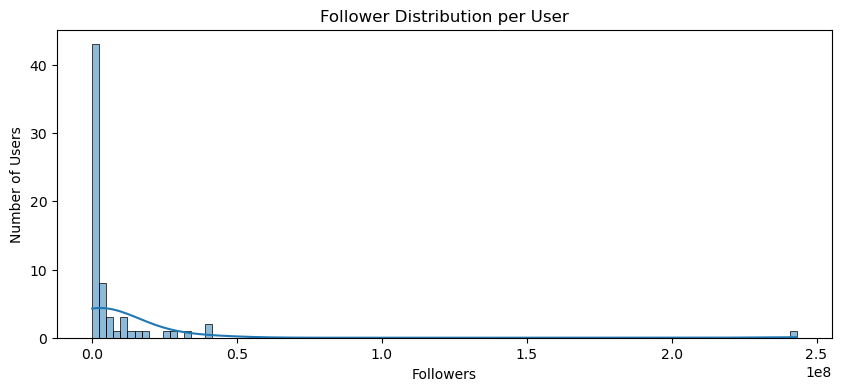

Minimum number of followers: 33
Maximum number of followers: 243184375


In [120]:
# Get max number of followers for each user (in case follower count changes in different posts)
user_followers = (
    df.groupby('user_id')['followers']
      .max()
)

plt.figure(figsize=(10, 4))
sns.histplot(user_followers, bins=100, kde=True)
plt.title("Follower Distribution per User")
plt.xlabel("Followers")
plt.ylabel("Number of Users")
plt.show()

print(f"Minimum number of followers: {user_followers.min()}")
print(f"Maximum number of followers: {user_followers.max()}")

Most users in this dataset had few followers, and some have very high number of followers.

### Follower distribution across all posts

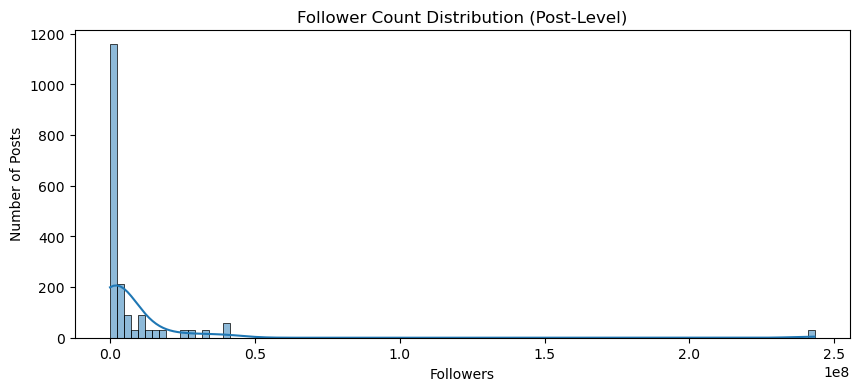

Minimum number of followers: 33
Maximum number of followers: 243184375


In [121]:
# Follower distribution
plt.figure(figsize=(10, 4))
sns.histplot(df['followers'], bins=100, kde=True)
plt.title("Follower Count Distribution (Post-Level)")
plt.xlabel("Followers")
plt.ylabel("Number of Posts")
plt.show()

print(f"Minimum number of followers: {df['followers'].min()}")
print(f"Maximum number of followers: {df['followers'].max()}")


User-level follower distributions were additionally inspected and found to be similar to post-level distributions, indicating limited sampling bias from repeated postings by the same accounts.

### Follower VS engagement rate

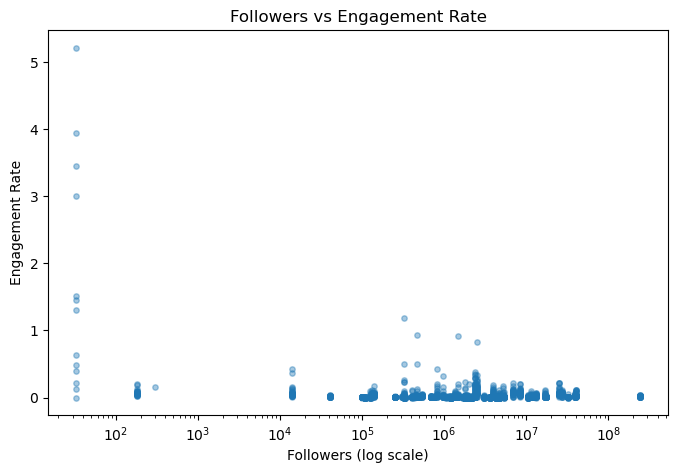

In [122]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['followers'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xscale('log') # log scale on followers due to wide range
plt.xlabel('Followers (log scale)')
plt.ylabel('Engagement Rate')
plt.title('Followers vs Engagement Rate')
plt.show()


Observations:
* Most posts have low engagement rate regardless of Followers count
* Posts with highest engagement rates also have the least followers. These could be close acquaintances or niche accounts with a close following.
* Posts with moderate engagement rates have slightly high follower count.
* Engagement rate could be almost inversely proportional to Followers count.

## Following

### Following count across users

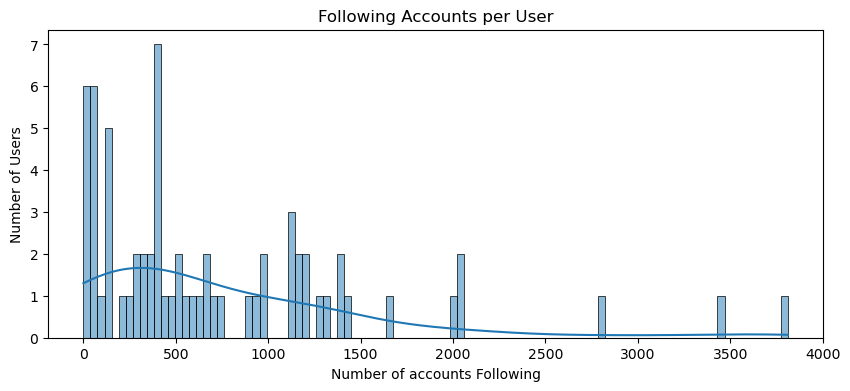

Minimum number of accounts following: 0
Maximum number of accounts following: 3812


In [123]:
# Get max number of accounts following, for each user (in case following count changes in different posts)
user_following = (
    df.groupby('user_id')['following']
      .max()
)

plt.figure(figsize=(10, 4))
sns.histplot(user_following, bins=100, kde=True)
plt.title("Following Accounts per User")
plt.xlabel("Number of accounts Following")
plt.ylabel("Number of Users")
plt.show()

print(f"Minimum number of accounts following: {user_following.min()}")
print(f"Maximum number of accounts following: {user_following.max()}")

### Following VS Engagement rate

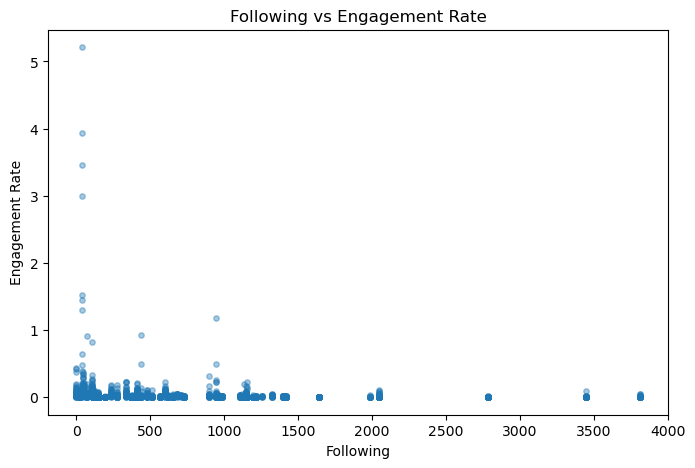

In [124]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['following'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Following')
plt.ylabel('Engagement Rate')
plt.title('Following vs Engagement Rate')
plt.show()

## Followers VS Following

### Followers VS following, at various engagement rates

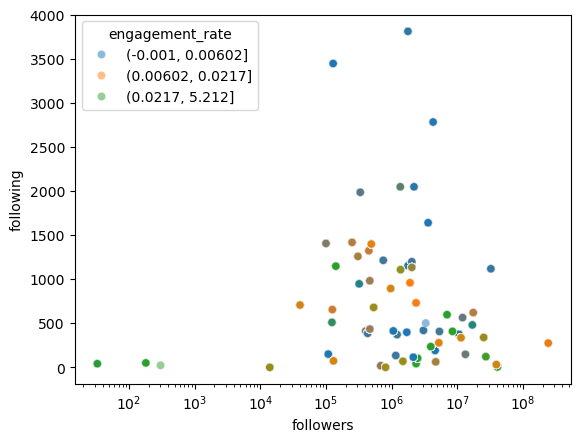

In [125]:
sns.scatterplot(
    x='followers',
    y='following',
    hue=pd.qcut(df['engagement_rate'], 3),
    data=df,
    alpha=0.5
)
plt.xscale('log')
plt.show()

Posts with the lowest engagement rates had moderate number of followers and a range of number of accounts following.

### Follower-following ratio

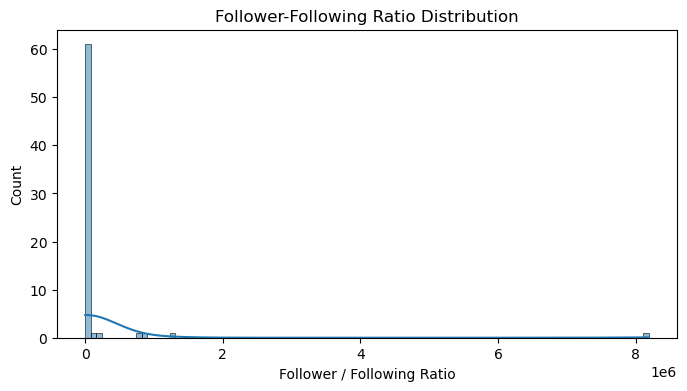

Minimum ratio: 0.8095238095238095
Maximum ratio: 8191915.4


In [126]:
df['follower_following_ratio'] = (df['followers'] + 1) / (df['following'] + 1)

# Get max number of accounts following, for each user (in case following count changes in different posts)
user_ff_ratio = (
    df.groupby('user_id')['follower_following_ratio']
      .max()
)

plt.figure(figsize=(8, 4))
sns.histplot(user_ff_ratio, bins=100, kde=True)
plt.xlabel('Follower / Following Ratio')
plt.title('Follower-Following Ratio Distribution')
plt.show()

print(f"Minimum ratio: {user_ff_ratio.min()}")
print(f"Maximum ratio: {user_ff_ratio.max()}")

Most users have much more accounts they are following, than followers.

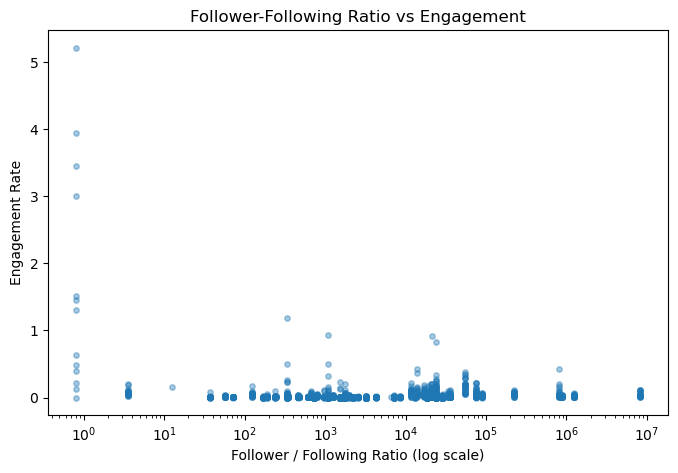

In [127]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['follower_following_ratio'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xscale('log')
plt.xlabel('Follower / Following Ratio (log scale)')
plt.ylabel('Engagement Rate')
plt.title('Follower-Following Ratio vs Engagement')
plt.show()


Posts with much higher following count than follower count also had higher engagement rate.

C:\Users\sugar\AppData\Local\Temp\ipykernel_12600\3777844150.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('ratio_bin')['engagement_rate'].median().plot(kind='bar')


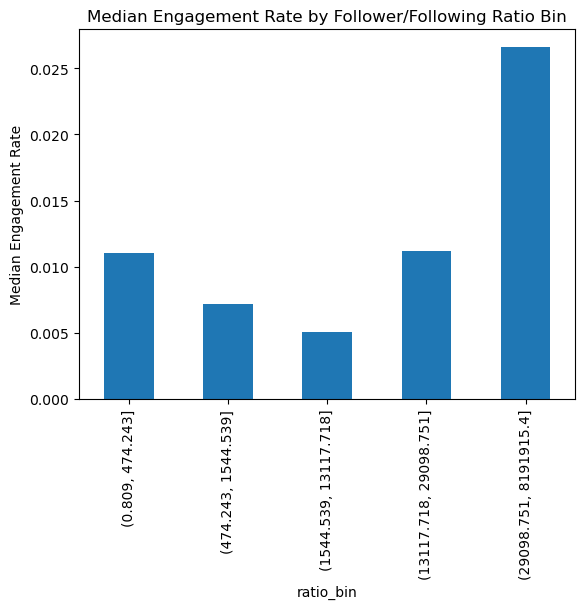

In [128]:
df['ratio_bin'] = pd.qcut(df['follower_following_ratio'], q=5)

df.groupby('ratio_bin')['engagement_rate'].median().plot(kind='bar')
plt.ylabel('Median Engagement Rate')
plt.title('Median Engagement Rate by Follower/Following Ratio Bin')
plt.show()


Low ratio (many following relative to followers)
→ moderate engagement

Mid ratio
→ lowest engagement

High ratio (many followers, few following)
→ highest median engagement

While scatter plots suggested occasional high engagement for posts from low follower–following ratio accounts, binned median analysis revealed that high-ratio accounts achieved higher typical engagement. This indicates higher variance among low-ratio accounts and more consistent engagement among high-ratio accounts.

In [129]:
df = df.drop(columns=['ratio_bin'])

## Publish timestamp (UTC) -> Hour and Day of post, weekend flag

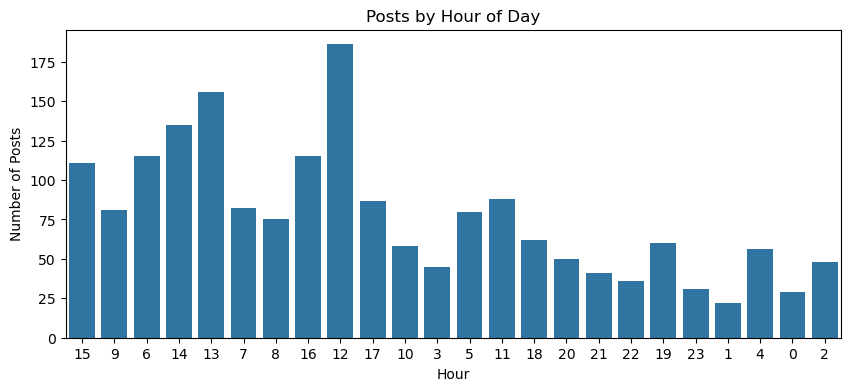

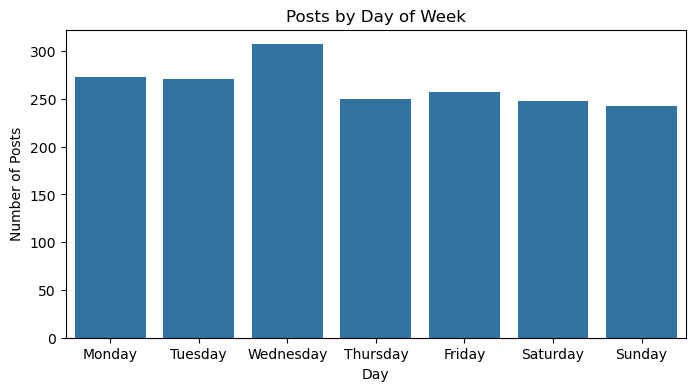

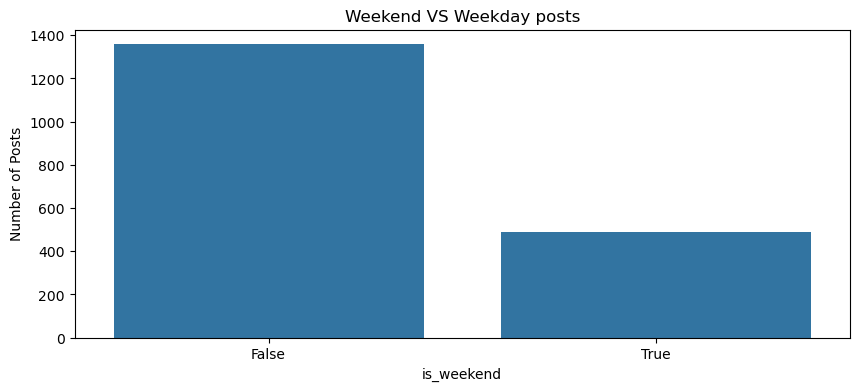

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to datetime
df['publish_timestamp'] = pd.to_datetime(df['publish_timestamp'], errors='coerce')

# Extract post hour and day
df['hour'] = df['publish_timestamp'].dt.hour.astype(str)
df['day'] = df['publish_timestamp'].dt.day_name()

# Extract weekend flag from post day
df['is_weekend'] = df['day'].isin(['Saturday', 'Sunday'])

# Hourly posting pattern
plt.figure(figsize=(10, 4))
sns.countplot(x='hour', data=df)
plt.title("Posts by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Posts")
plt.show()

# Daily pattern
plt.figure(figsize=(8, 4))
sns.countplot(x='day', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Posts by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Posts")
plt.show()

# Weekend vs weekday
plt.figure(figsize=(10, 4))
sns.countplot(x='is_weekend', data=df)
plt.title("Weekend VS Weekday posts")
plt.xlabel("is_weekend")
plt.ylabel("Number of Posts")
plt.show()

### Likes and comments per hour

Minimum likes: 0
Maximum likes: 10174432
Minimum comments: 0
Maximum comments: 693966


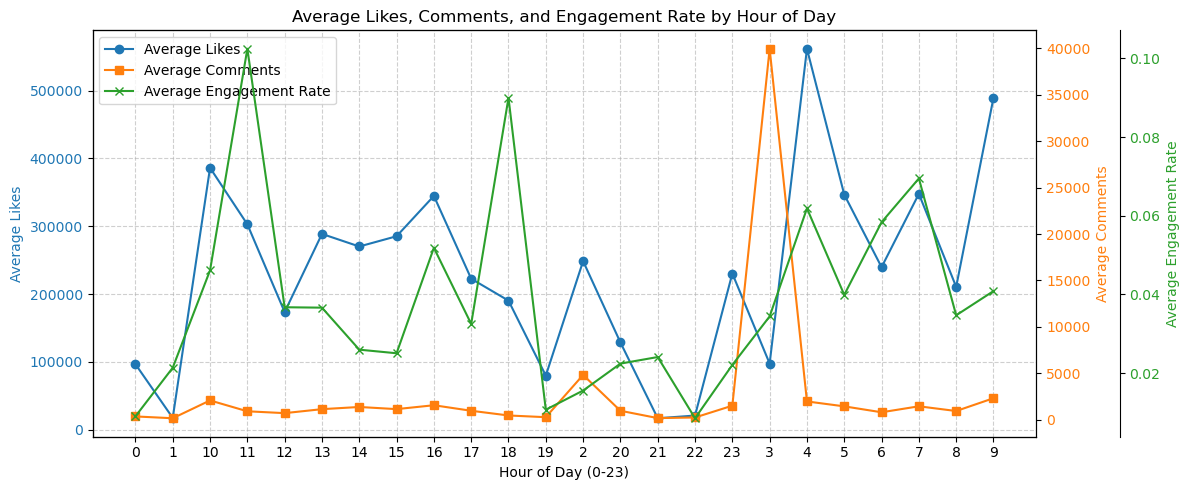

In [131]:
# Group by hour
hourly_stats = df.groupby('hour')[['likes', 'comments', 'engagement_rate']].mean()

print(f"Minimum likes: {df['likes'].min()}")
print(f"Maximum likes: {df['likes'].max()}")
print(f"Minimum comments: {df['comments'].min()}")
print(f"Maximum comments: {df['comments'].max()}")

fig, ax1 = plt.subplots(figsize=(12, 5))

# Likes (left y-axis)
color_likes = 'tab:blue'
ax1.plot(
    hourly_stats.index,
    hourly_stats['likes'],
    marker='o',
    label='Average Likes',
    color=color_likes
)
ax1.set_xlabel('Hour of Day (0-23)')
ax1.set_ylabel('Average Likes', color=color_likes)
ax1.tick_params(axis='y', labelcolor=color_likes)
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle='--', alpha=0.6)

# Comments (right y-axis)
color_comments = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(
    hourly_stats.index,
    hourly_stats['comments'],
    marker='s',
    label='Average Comments',
    color=color_comments
)
ax2.set_ylabel('Average Comments', color=color_comments)
ax2.tick_params(axis='y', labelcolor=color_comments)

# Engagement rate (second right y-axis, offset)
color_engagement = 'tab:green'
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(
    hourly_stats.index,
    hourly_stats['engagement_rate'],
    marker='x',
    label='Average Engagement Rate',
    color=color_engagement
)
ax3.set_ylabel('Average Engagement Rate', color=color_engagement)
ax3.tick_params(axis='y', labelcolor=color_engagement)

# Combined legend
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Average Likes, Comments, and Engagement Rate by Hour of Day')
plt.tight_layout()
plt.show()


* Note: Hour of Day is in UTC time, and since the timezone of the posts is not shown, the observations may not be reliable
* This is shown by the odd higher comments and likes from 3 to 4AM.
* The average engagement rate peaks at 11AM and 6PM, which could roughly coincide with meal times, but again this may not be reliable.

### Likes and comments per day

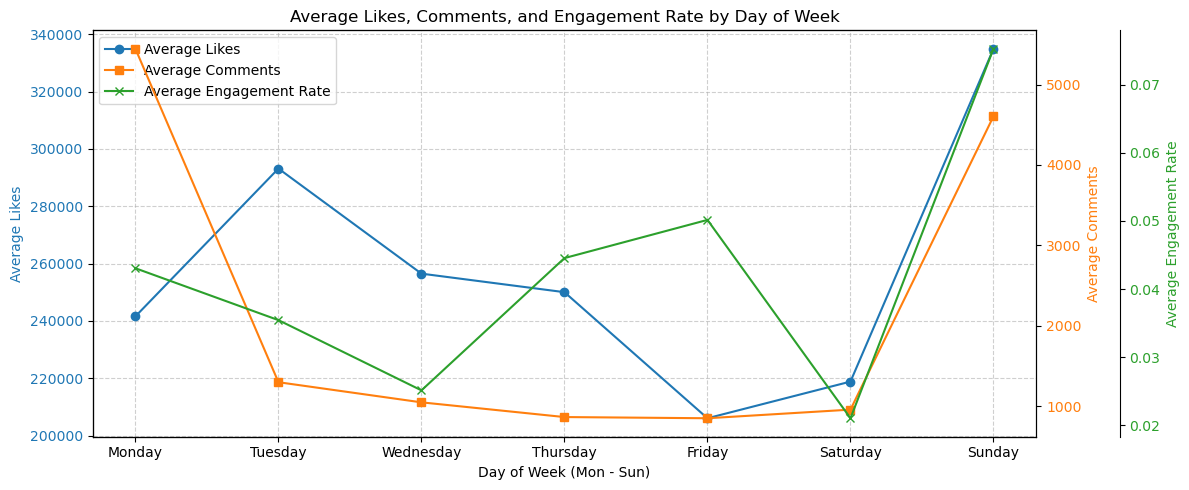

In [132]:
# Set weekday order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Group by day
daily_stats = df.groupby('day')[['likes', 'comments', 'engagement_rate']].mean().reindex(days_order)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Likes (left y-axis)
color_likes = 'tab:blue'
ax1.plot(
    daily_stats.index,
    daily_stats['likes'],
    marker='o',
    label='Average Likes',
    color=color_likes
)
ax1.set_xlabel('Day of Week (Mon - Sun)')
ax1.set_ylabel('Average Likes', color=color_likes)
ax1.tick_params(axis='y', labelcolor=color_likes)
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle='--', alpha=0.6)

# Comments (right y-axis)
color_comments = 'tab:orange'
ax2 = ax1.twinx()
ax2.plot(
    daily_stats.index,
    daily_stats['comments'],
    marker='s',
    label='Average Comments',
    color=color_comments
)
ax2.set_ylabel('Average Comments', color=color_comments)
ax2.tick_params(axis='y', labelcolor=color_comments)

# Engagement rate (second right y-axis, offset)
color_engagement = 'tab:green'
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(
    daily_stats.index,
    daily_stats['engagement_rate'],
    marker='x',
    label='Average Engagement Rate',
    color=color_engagement
)
ax3.set_ylabel('Average Engagement Rate', color=color_engagement)
ax3.tick_params(axis='y', labelcolor=color_engagement)

# Combined legend
lines = ax1.get_lines() + ax2.get_lines() + ax3.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Average Likes, Comments, and Engagement Rate by Day of Week')
plt.tight_layout()
plt.show()

* Average likes, comments and engagement rates peak on Sunday

## Binary features (has_location, is_carousel, is_sponsored)

### has_location

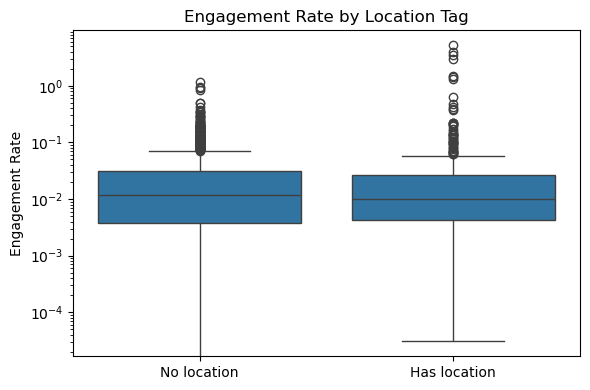

In [133]:
plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    x='has_location',
    y='engagement_rate',
    data=df,
    order=[0, 1]
)
ax.set_yscale('log') # for visibility of box plot
ax.set_xticks([0, 1])
ax.set_xticklabels(['No location', 'Has location'])
plt.xlabel('')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by Location Tag')
plt.tight_layout()
plt.show()


* Median engagement rate is below 0 whether or not Location information in included in the post.
* Since engagement rate is (likes + comments) / followers,
* this means followers is always greater than likes + comments, no new audiences reached. This makes sense.
* When location information is included, there are more outliers where likes + comments > followers.
* This also makes sense because other people who are not followers can find these posts by location.

### is_carousel

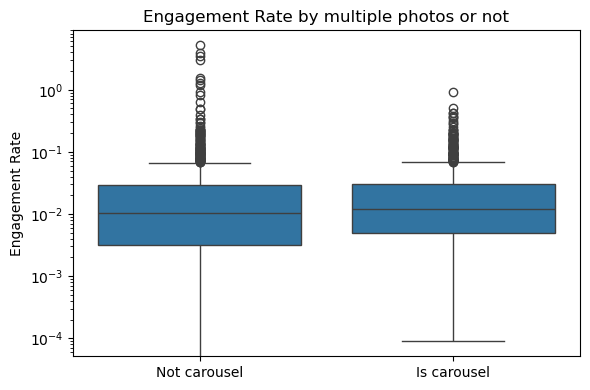

In [134]:
plt.figure(figsize=(6, 4))
ax=sns.boxplot(
    x='is_carousel',
    y='engagement_rate',
    data=df,
    order=[0, 1]
)
ax.set_yscale('log') # for visibility of box plot
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not carousel', 'Is carousel'])
plt.xlabel('')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by multiple photos or not')
plt.tight_layout()
plt.show()


* Median engagement rate is below 0 whether or not the post is a carousel or not.
* Since engagement rate is (likes + comments) / followers,
* this means followers is always greater than likes + comments, no new audiences reached. This makes sense.
* Likes + comments count > followers sometimes when the post is not a carousel, maybe because new audiences interact on impulse by looking at the first image.

### is_sponsored

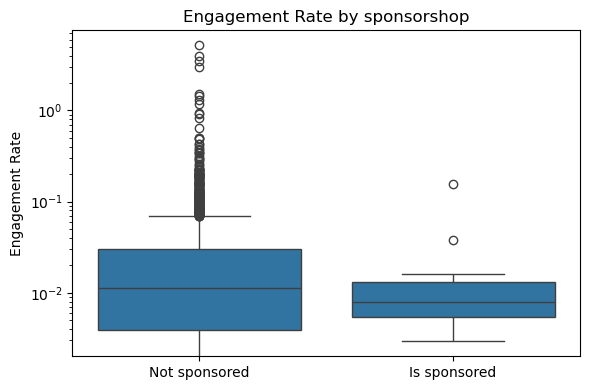

In [135]:
plt.figure(figsize=(6, 4))
ax=sns.boxplot(
    x='is_sponsored',
    y='engagement_rate',
    data=df,
    order=[0, 1]
)
ax.set_yscale('log') # for visibility of box plot
ax.set_xticks([0, 1])
ax.set_xticklabels(['Not sponsored', 'Is sponsored'])
plt.xlabel('')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by sponsorshop')
plt.tight_layout()
plt.show()

* Median engagement rate is below 0 whether or not the post is sponsored.
* Since engagement rate is (likes + comments) / followers,
* this means followers is always greater than likes + comments, no new audiences reached. This makes sense.
* Non-sponsored posts have a much wider range in engagement rate, and likes + comments can exceed follower count.
* Sponsored posts have slightly lower median engagement rate, suggesting that audiences dislike sponsored posts.

## Captions

### Word count in caption

In [136]:
import pandas as pd
import re

def clean_caption_no_hashtag(text):
    if not isinstance(text, str):
        return 0
    # split text into words
    words = text.lower().split()
    # only keep words that **do not start with #**
    words = [w for w in words if not w.startswith('#')]
    # optionally, keep only alphanumeric parts
    words = [re.sub(r'\W+', '', w) for w in words if re.sub(r'\W+', '', w)]
    return len(words)


df['caption_word_count'] = df['caption'].apply(clean_caption_no_hashtag)
df[['caption', 'caption_word_count']].head()

,caption,caption_word_count
0,Bonjour Paree 🥐 ready for a Parisian Christmas...,9
1,Just popping in to wish you a Merry Christmas ...,24
2,Louvre Day 💙,2
3,Happy 2023 from our frozen but happy faces 🥰\n...,65
4,🧇 on my mind,3


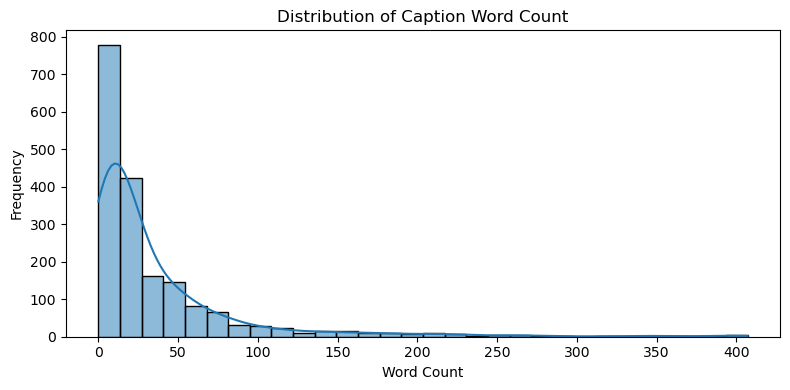

Minimum caption word count: 0
Maximum caption word count: 407
Median caption word count: 17.0
count    1849.000000
mean       35.718767
std        53.970329
min         0.000000
25%         6.000000
50%        17.000000
75%        43.000000
max       407.000000
Name: caption_word_count, dtype: float64


In [137]:
plt.figure(figsize=(8,4))
sns.histplot(df['caption_word_count'], bins=30, kde=True)
plt.title('Distribution of Caption Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f"Minimum caption word count: {df['caption_word_count'].min()}")
print(f"Maximum caption word count: {df['caption_word_count'].max()}")
print(f"Median caption word count: {df['caption_word_count'].median()}")
print(df['caption_word_count'].describe())


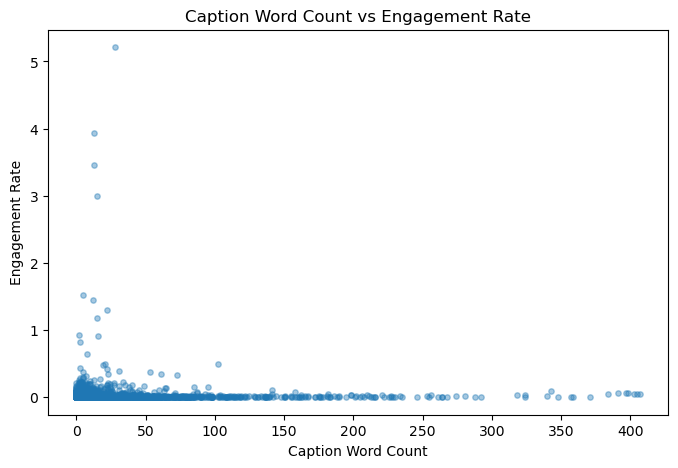

In [138]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['caption_word_count'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Caption Word Count')
plt.ylabel('Engagement Rate')
plt.title('Caption Word Count vs Engagement Rate')
plt.show()

* Most captions are very short, less than 50 words. 
* Posts with the highest engagement rate also had very short captions.

### Extract hashtags from caption
Also add flag for whether post contains hashtags, and if any posts are clearly ads using the #ads hashtag

In [139]:
# Add list of hashtags as new feature
df["hashtags"] = df["caption"].str.findall(r"#\w+")
df["hashtags"] = (
    df["hashtags"]
    .apply(lambda tags: [t[1:].lower() for t in tags])
)

# Add feature for number of hashtags
df["num_hashtags"] = df["hashtags"].apply(len)

# Check if any posts are clearly ads using the #ads hashtag
df["ads"] = df["hashtags"].str.contains(r"ad", na=False)


In [140]:
df["ads"].value_counts()

ads
False    1849
Name: count, dtype: int64

In [141]:
df = df.drop(columns=['ads'])

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   1849 non-null   object        
 1   followers                 1849 non-null   int64         
 2   following                 1849 non-null   int64         
 3   publish_timestamp         1849 non-null   datetime64[ns]
 4   has_location              1849 non-null   int64         
 5   is_carousel               1849 non-null   int64         
 6   num_images                1849 non-null   int64         
 7   is_sponsored              1849 non-null   int64         
 8   image_path                1849 non-null   object        
 9   caption                   1849 non-null   object        
 10  likes                     1849 non-null   int64         
 11  comments                  1849 non-null   int64         
 12  engagement_rate     

### Number of hashtags

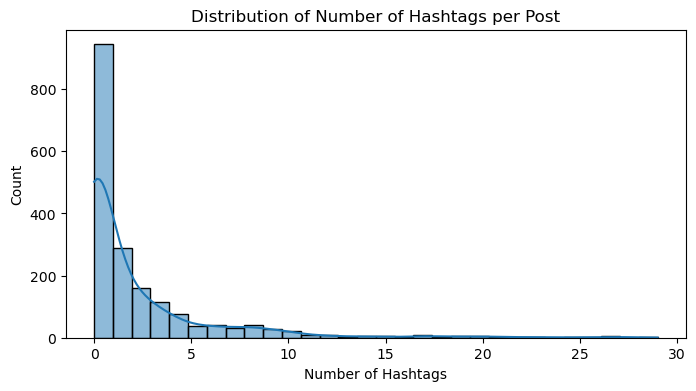

Minimum number of hashtags: 0
Maximum number of hashtags: 29
Median number of hashtags: 0.0


In [143]:
plt.figure(figsize=(8,4))
sns.histplot(df["num_hashtags"], bins=30, kde=True)
plt.title("Distribution of Number of Hashtags per Post")
plt.xlabel("Number of Hashtags")
plt.ylabel("Count")
plt.show()

print(f"Minimum number of hashtags: {df['num_hashtags'].min()}")
print(f"Maximum number of hashtags: {df['num_hashtags'].max()}")
print(f"Median number of hashtags: {df['num_hashtags'].median()}")

### Engagement rate VS number of hashtags

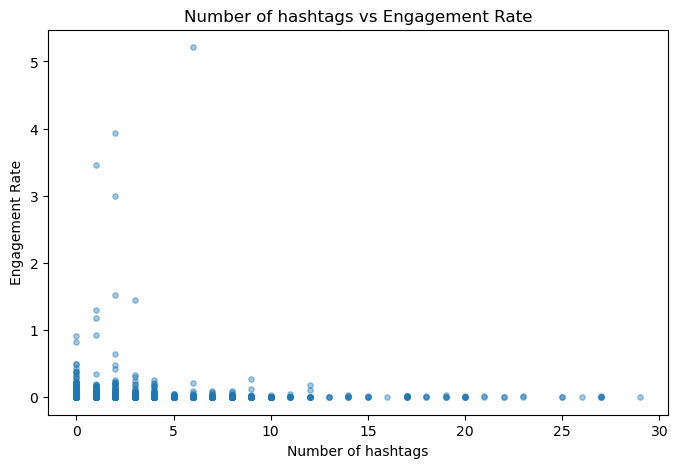

In [144]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['num_hashtags'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Number of hashtags')
plt.ylabel('Engagement Rate')
plt.title('Number of hashtags vs Engagement Rate')
plt.show()

The number of hashtags do not really affect engagement rate, and a few posts have varying engagement rates while having few hashtags.

## Number of Images

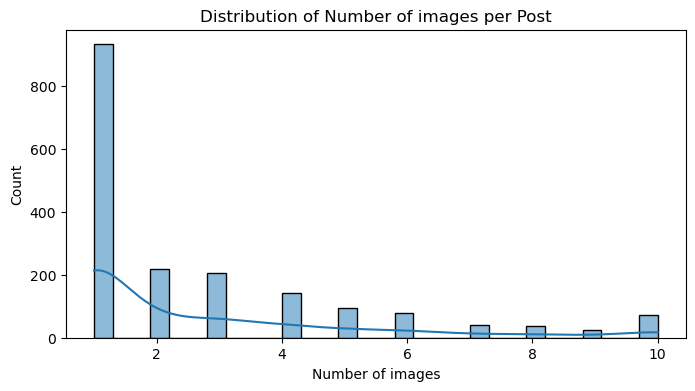

Minimum number of images: 1
Maximum number of images: 10
Median number of images: 1.0


In [145]:
plt.figure(figsize=(8,4))
sns.histplot(df["num_images"], bins=30, kde=True)
plt.title("Distribution of Number of images per Post")
plt.xlabel("Number of images")
plt.ylabel("Count")
plt.show()

print(f"Minimum number of images: {df['num_images'].min()}")
print(f"Maximum number of images: {df['num_images'].max()}")
print(f"Median number of images: {df['num_images'].median()}")

### Engagement rate VS number of images

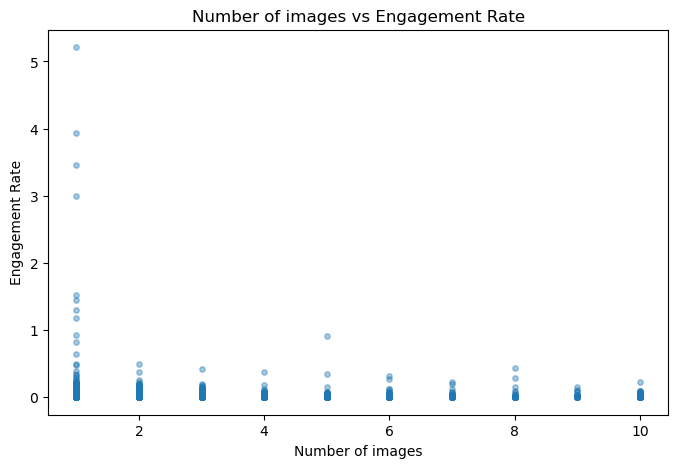

Minimum number of images: 1
Maximum number of images: 10


In [146]:
plt.figure(figsize=(8, 5))
plt.scatter(
    df['num_images'],
    df['engagement_rate'],
    alpha=0.4,
    s=15
)
plt.xlabel('Number of images')
plt.ylabel('Engagement Rate')
plt.title('Number of images vs Engagement Rate')
plt.show()

print(f"Minimum number of images: {df['num_images'].min()}")
print(f"Maximum number of images: {df['num_images'].max()}")

The number of images does not affect the engagement rate. The posts with highest engagement rate only have 1 image.

## Engagement rate

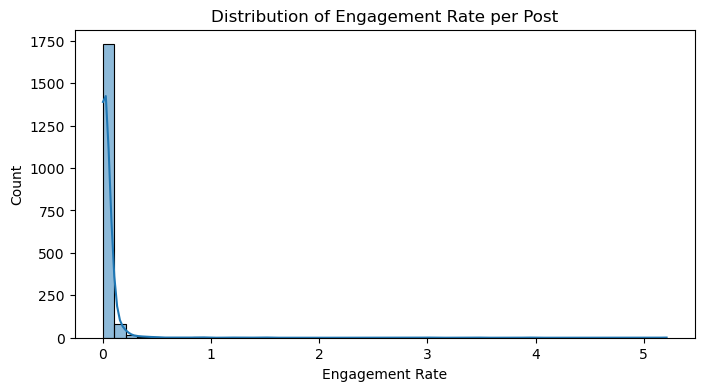

Minimum Engagement Rate: 0.0
Maximum Engagement Rate: 5.212121212121212
Median Engagement Rate: 0.011276653925336859
count    1849.000000
mean        0.041435
std         0.203975
min         0.000000
25%         0.003981
50%         0.011277
75%         0.030087
max         5.212121
Name: engagement_rate, dtype: float64


In [147]:
plt.figure(figsize=(8,4))
sns.histplot(df["engagement_rate"], bins=50, kde=True)
plt.title("Distribution of Engagement Rate per Post")
plt.xlabel("Engagement Rate")
plt.ylabel("Count")
plt.show()

print(f"Minimum Engagement Rate: {df['engagement_rate'].min()}")
print(f"Maximum Engagement Rate: {df['engagement_rate'].max()}")
print(f"Median Engagement Rate: {df['engagement_rate'].median()}")
print(df['engagement_rate'].describe())

In [148]:
df["engagement_rate"].quantile(0.66)

np.float64(0.021062562551267434)

## Class engagement rate into bins

In [149]:

# Quantile-based classes
low = df["engagement_rate"].quantile(0.33)
high = df["engagement_rate"].quantile(0.66)

def label_engagement(x, low, high):
    if x <= low:
        return 0  # low
    elif x <= high:
        return 1  # medium
    else:
        return 2  # high

# Label by quantile
df["engagement_label"] = df["engagement_rate"].apply(label_engagement, args=(low, high))

# Label by benchmark ranges 
# df["engagement_label"] = df["engagement_rate"].apply(label_engagement, args=(1, 3.5))


In [150]:
df["engagement_label"].value_counts()

engagement_label
2    629
1    610
0    610
Name: count, dtype: int64

### Drop features used to make final target label to avoid leakage

In [151]:
df = df.drop(columns=["likes","comments","engagement_rate","followers"])

To prevent target leakage, features directly involved in the computation of engagement labels, including likes, comments, and engagement rate, were excluded from the model inputs. Follower count was also omitted to avoid mathematical coupling with the target.

# Feature interactions

In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1849 entries, 0 to 1848
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   1849 non-null   object        
 1   following                 1849 non-null   int64         
 2   publish_timestamp         1849 non-null   datetime64[ns]
 3   has_location              1849 non-null   int64         
 4   is_carousel               1849 non-null   int64         
 5   num_images                1849 non-null   int64         
 6   is_sponsored              1849 non-null   int64         
 7   image_path                1849 non-null   object        
 8   caption                   1849 non-null   object        
 9   follower_following_ratio  1849 non-null   float64       
 10  hour                      1849 non-null   object        
 11  day                       1849 non-null   object        
 12  is_weekend          

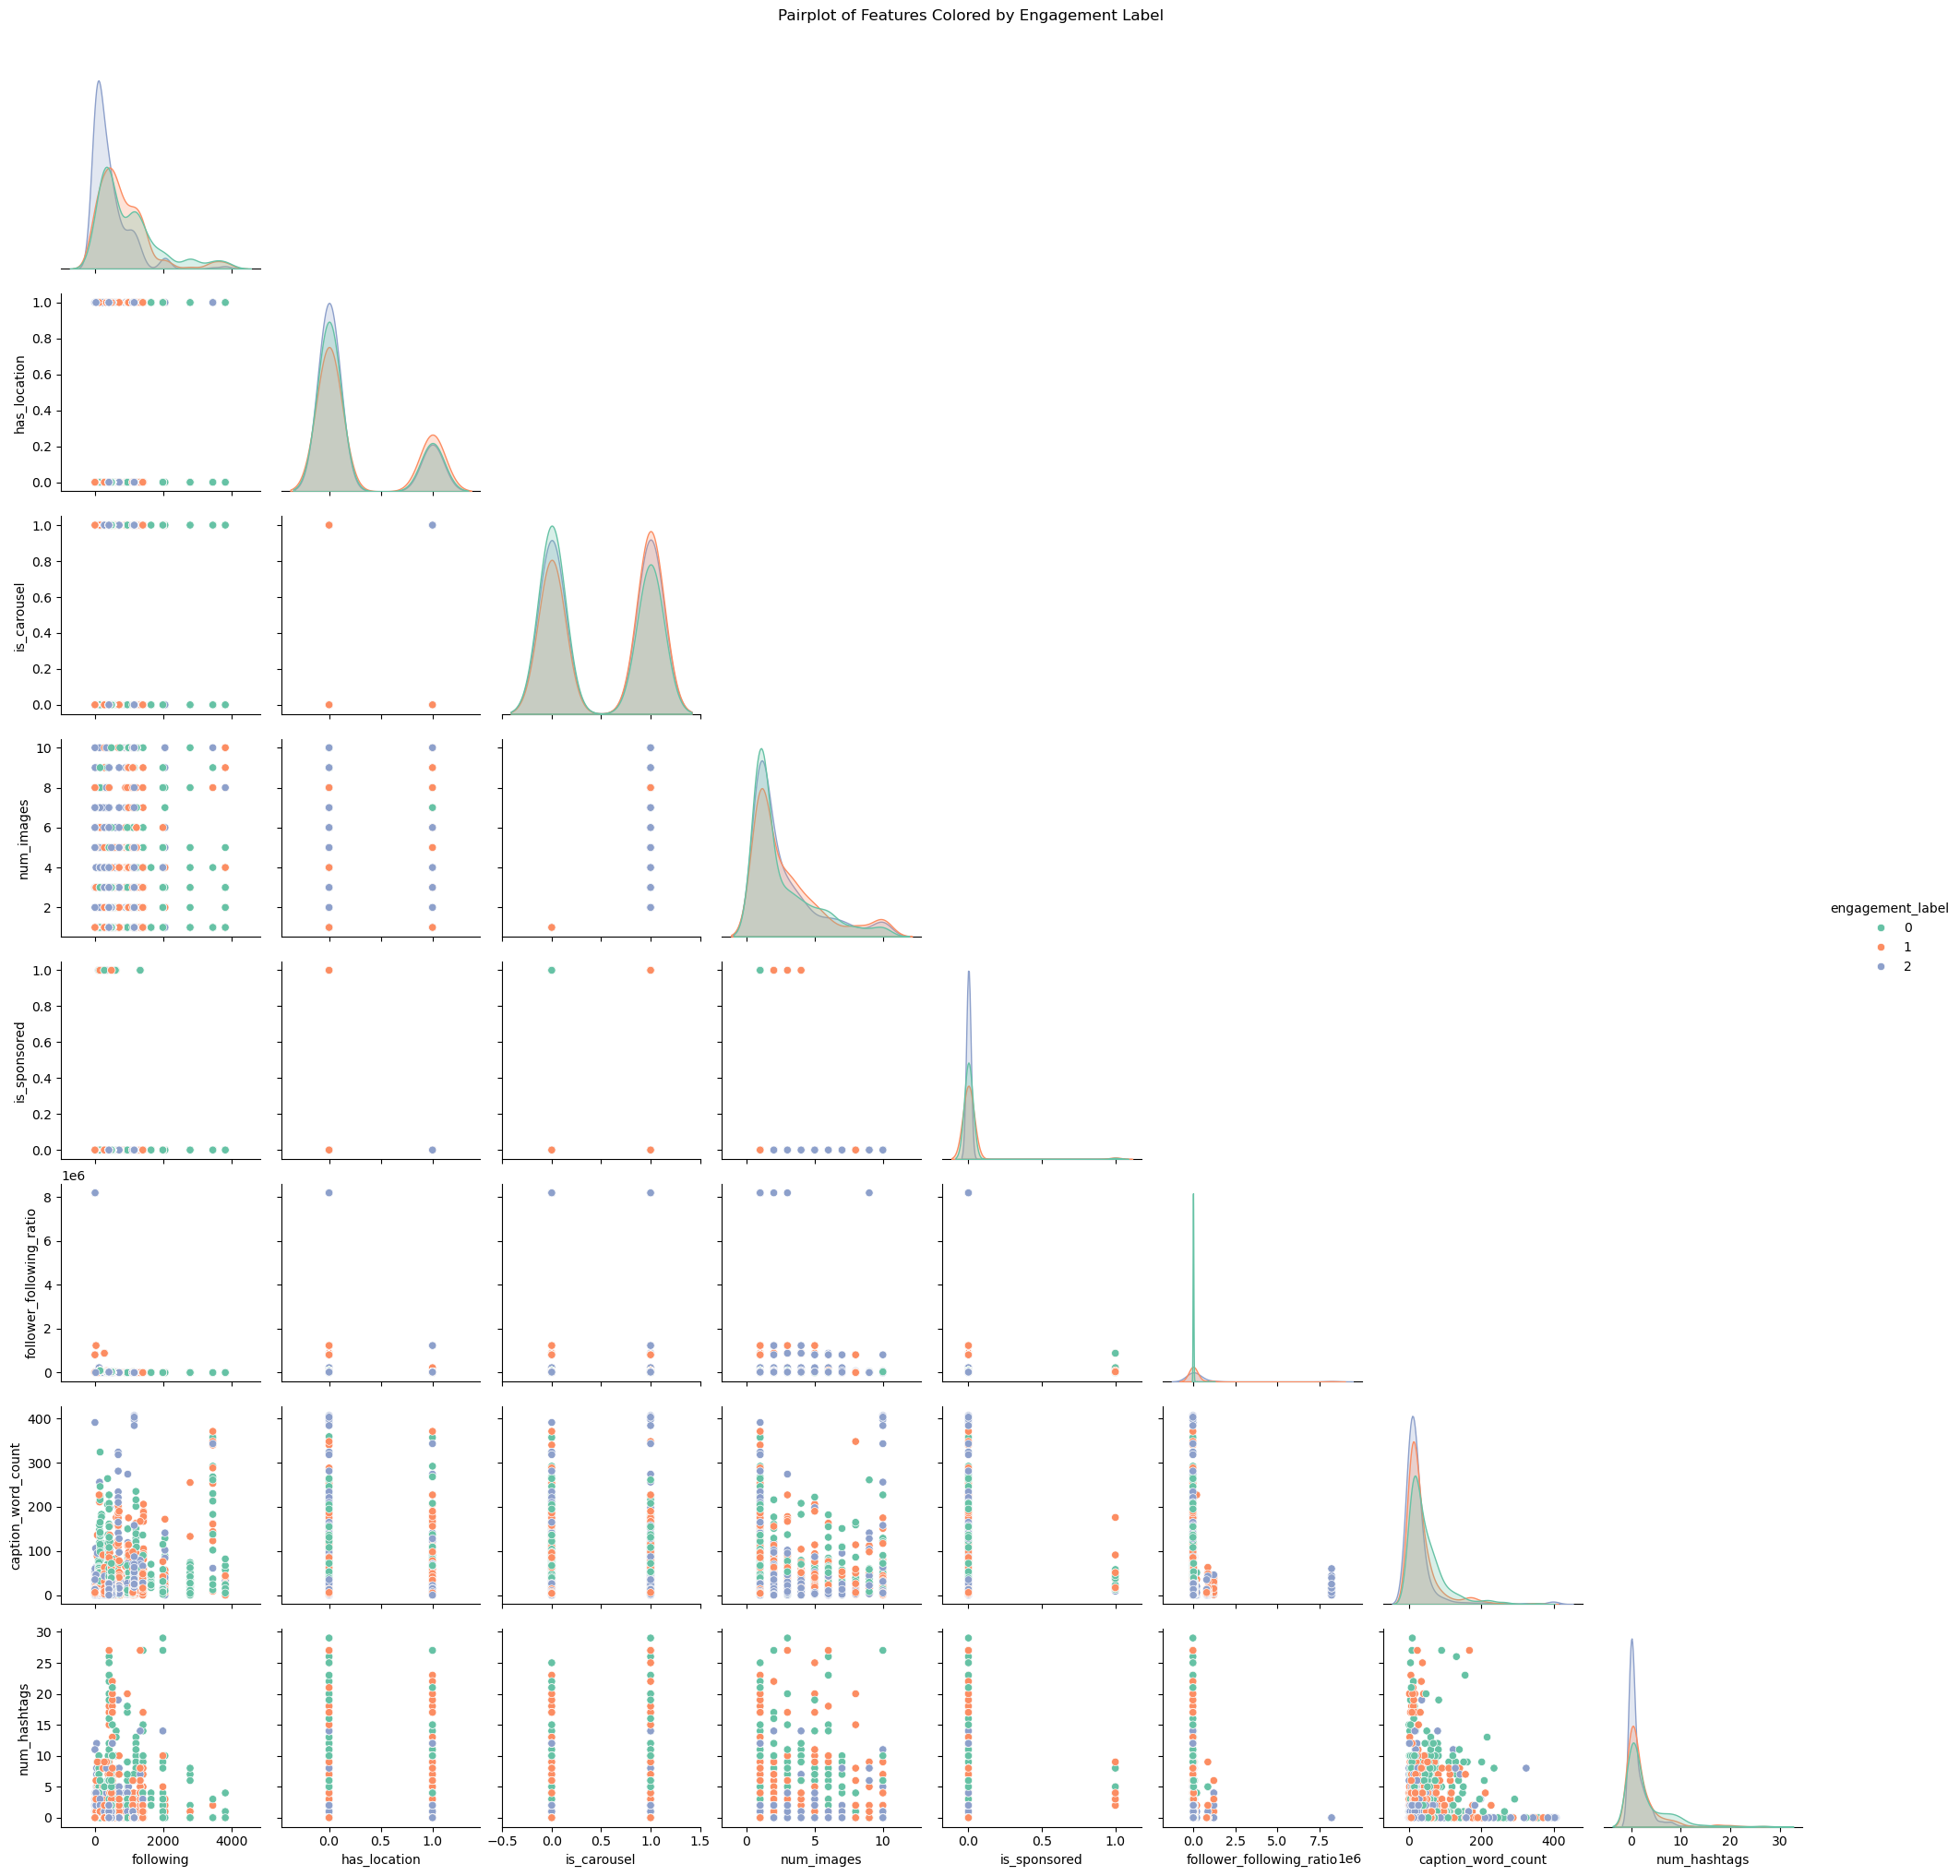

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get numeric columns including engagement_label
numeric_cols = df.select_dtypes(include='number').columns.tolist()

# Pairplot
hue_labels = {0: "Low", 1: "Medium", 2: "High"}
sns.pairplot(df[numeric_cols], hue="engagement_label",
             palette="Set2", diag_kind="kde", corner=True)

plt.suptitle("Pairplot of Features Colored by Engagement Label", y=1.02)
plt.show()



Looking at the pairplots, there are no clear interactions between the features to form higher/lower engagement rates. This is shown from the mix in engagement labels across the plot.

# Data processing

## Train test split

Data was split temporally within each user, using earlier posts for training and later posts for testing to simulate real-world post evaluation.

In [154]:
df = df.sort_values(["user_id", "publish_timestamp"])

def temporal_split(group, train_frac=0.8):
    split_idx = int(len(group) * train_frac)
    return group.iloc[:split_idx], group.iloc[split_idx:]

train_parts = []
test_parts = []

for _, g in df.groupby("user_id"):
    if len(g) >= 3:  # avoid tiny histories
        tr, te = temporal_split(g)
        train_parts.append(tr)
        test_parts.append(te)

train_df = pd.concat(train_parts)
test_df  = pd.concat(test_parts)


#### 1. Check that there is no future leakage within each user

In [155]:
violations = []

for user_id in train_df['user_id'].unique():
    train_times = train_df.loc[train_df['user_id'] == user_id, 'publish_timestamp']
    test_times  = test_df.loc[test_df['user_id'] == user_id, 'publish_timestamp']

    if not test_times.empty:
        if train_times.max() > test_times.min():
            violations.append(user_id)

len(violations)


0

#### 2. Check that each user appears in both sets

In [156]:
common_users = set(train_df['user_id']) & set(test_df['user_id'])

len(common_users), train_df['user_id'].nunique(), test_df['user_id'].nunique()

(65, 65, 65)


#### 3. Check label distribution for class imbalance (should be around 33% each)

In [157]:
def label_dist(df, name):
    print(f"\n{name} label distribution:")
    print(df['engagement_label'].value_counts(normalize=True))

label_dist(train_df, "Train")
label_dist(test_df, "Test")



Train label distribution:
engagement_label
2    0.348742
1    0.337186
0    0.314072
Name: proportion, dtype: float64

Test label distribution:
engagement_label
0    0.390957
2    0.305851
1    0.303191
Name: proportion, dtype: float64


#### 4. Check that each user has enough history

In [ ]:

min_posts_train = train_df.groupby("user_id").size().min()
min_posts_test  = test_df.groupby("user_id").size().min()

min_posts_train, min_posts_test


(6, 2)

#### Pick random user to check split

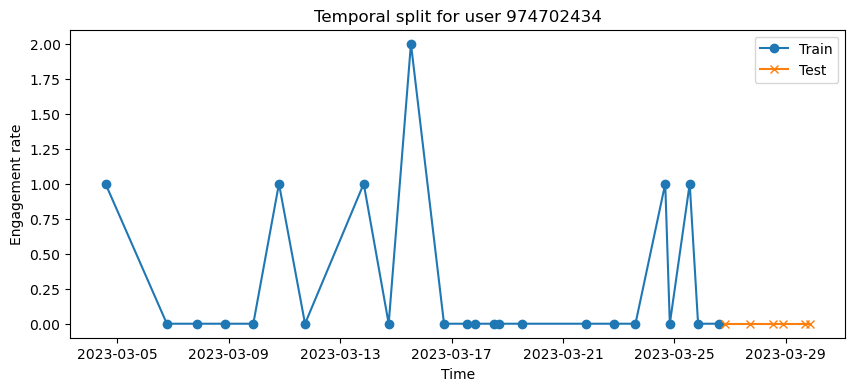

In [159]:
import matplotlib.pyplot as plt
import numpy as np

user = np.random.choice(train_df['user_id'].unique())

plt.figure(figsize=(10,4))

plt.plot(
    train_df[train_df['user_id'] == user]['publish_timestamp'],
    train_df[train_df['user_id'] == user]['engagement_label'],
    label='Train', marker='o'
)

plt.plot(
    test_df[test_df['user_id'] == user]['publish_timestamp'],
    test_df[test_df['user_id'] == user]['engagement_label'],
    label='Test', marker='x'
)

plt.title(f"Temporal split for user {user}")
plt.xlabel("Time")
plt.ylabel("Engagement rate")
plt.legend()
plt.show()


In [160]:
assert train_df[train_df['user_id'] == user]['publish_timestamp'].max() < test_df[test_df['user_id'] == user]['publish_timestamp'].min()


# Export split data

In [161]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1471 entries, 488 to 1470
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   1471 non-null   object        
 1   following                 1471 non-null   int64         
 2   publish_timestamp         1471 non-null   datetime64[ns]
 3   has_location              1471 non-null   int64         
 4   is_carousel               1471 non-null   int64         
 5   num_images                1471 non-null   int64         
 6   is_sponsored              1471 non-null   int64         
 7   image_path                1471 non-null   object        
 8   caption                   1471 non-null   object        
 9   follower_following_ratio  1471 non-null   float64       
 10  hour                      1471 non-null   object        
 11  day                       1471 non-null   object        
 12  is_weekend             

In [162]:
if not os.path.exists('data'):
    os.makedirs('data')

train_df.to_csv("data/train_df.csv", index=False)
test_df.to_csv("data/test_df.csv", index=False)
